# Análise de dados UCI Heart Disease Data

**Contexto:** Este é um tipo de conjunto de dados multivariado, o que significa que fornece ou envolve uma variedade de variáveis matemáticas ou estatísticas distintas, sendo uma análise de dados numéricos multivariados. É composto por 14 atributos, que são: idade, sexo, tipo de dor no peito, pressão arterial em repouso, colesterol sérico, glicemia em jejum, resultados eletrocardiográficos em repouso, frequência cardíaca máxima alcançada, angina induzida por exercício, oldpeak — depressão do segmento ST induzida por exercício em relação ao repouso, a inclinação do segmento ST de pico no exercício, número de vasos principais e Talassemia.

Este banco de dados inclui 76 atributos, mas todos os estudos publicados referem-se ao uso de um subconjunto de 14 deles. O banco de dados de Cleveland é o único usado por pesquisadores de aprendizado de máquina (ML) até o momento.

Uma das principais tarefas neste conjunto de dados é prever, com base nos atributos fornecidos de um paciente, se essa pessoa em particular tem ou não uma doença cardíaca. A outra é a tarefa experimental de diagnosticar e extrair vários insights deste conjunto de dados que possam ajudar a entender melhor o problema.

## Carregamento e entendimento incial do dados

O primeiro passo pe carregar os dados e fazer a inspeção inicial, alinhado à fase de Data Understanding do CRISP-DM.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.frame import DataFrame

## Baixar dataset do Kaggle

Para começarmos a análise, é necessário que realizemos o download do dataset disponibilizado no kaggle.
Vamos carregar nosso dataset  e imprimir alguns dados iniciais de análise.

Dataset: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?resource=download

In [36]:
dataset_path = "data/heart_disease_uci.csv"

data_frame = pd.read_csv(dataset_path)

### Inspenção Inicial do dados (Shape e 10 primeiras linhas)

In [37]:
print(f"Shape dos dados: {data_frame.shape[0]} linhas - {data_frame.shape[1]} colunas")
print(f"\nPrimeiras linhas do dataset:")
data_frame.head(10)

Shape dos dados: 920 linhas - 16 colunas

Primeiras linhas do dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [38]:
print(f"\nÚltimas linhas do dataset:")
data_frame.tail(10)


Últimas linhas do dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
910,911,51,Female,VA Long Beach,asymptomatic,114.0,258.0,True,lv hypertrophy,96.0,False,1.0,upsloping,NaN,NaN,0
911,912,62,Male,VA Long Beach,asymptomatic,160.0,254.0,True,st-t abnormality,108.0,True,3.0,flat,NaN,NaN,4
912,913,53,Male,VA Long Beach,asymptomatic,144.0,300.0,True,st-t abnormality,128.0,True,1.5,flat,NaN,NaN,3
913,914,62,Male,VA Long Beach,asymptomatic,158.0,170.0,False,st-t abnormality,138.0,True,0.0,NaN,NaN,NaN,1
914,915,46,Male,VA Long Beach,asymptomatic,134.0,310.0,False,normal,126.0,False,0.0,NaN,NaN,normal,2
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


## Informações gerais sobre o dataset

In [39]:
print("=== INFORMAÇÕES GERAIS DO DATASET ===")
print(data_frame.info())

print("=== ESTATÍSTICAS DESCRITIVAS ===")
print(data_frame.describe())

=== INFORMAÇÕES GERAIS DO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None
=== ESTATÍSTICAS DESCRITIVAS ===
               id         age    trestbps        chol   

# Histograma dos dados

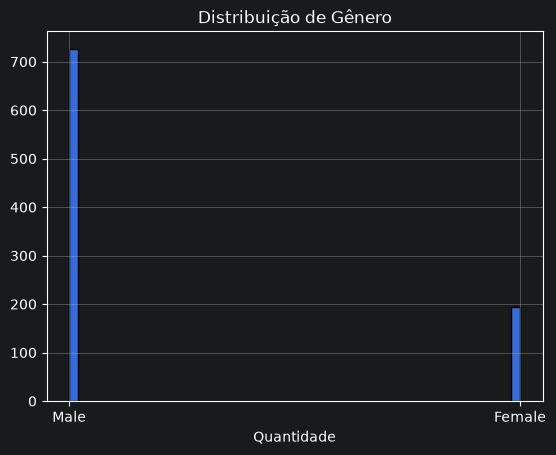

In [40]:
data_frame['sex'].hist(bins=50, edgecolor='black')

plt.title("Distribuição de Gênero")
plt.xlabel('Gênero')
plt.xlabel('Quantidade')
plt.show()

In [41]:
print("===== Contagem de valores nulos ===== ")
data_frame.isnull().sum()

===== Contagem de valores nulos ===== 


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

# Análise de valores nulos das colunas

           Colunas  Missing Values Count  Percent Missing values
ca              ca                   611                   66.41
thal          thal                   486                   52.83
slope        slope                   309                   33.59
fbs            fbs                    90                    9.78
oldpeak    oldpeak                    62                    6.74
trestbps  trestbps                    59                    6.41
exang        exang                    55                    5.98
thalch      thalch                    55                    5.98
chol          chol                    30                    3.26
restecg    restecg                     2                    0.22


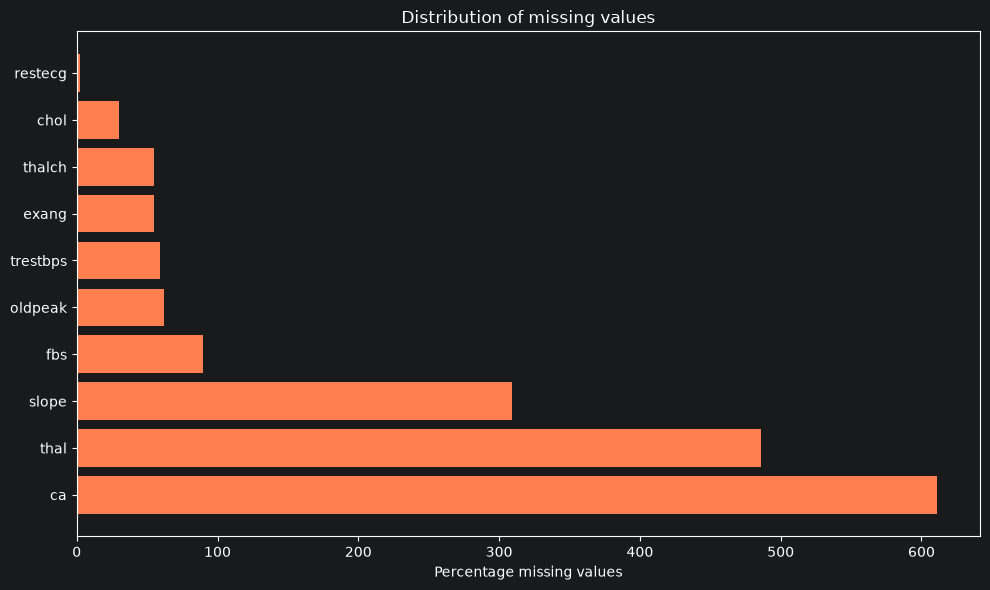

In [42]:
missing_values = pd.DataFrame({
    "Colunas": data_frame.columns,
    "Missing Values Count": data_frame.isnull().sum(),
    "Percent Missing values": (data_frame.isnull().sum() / len(data_frame) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing Values Count'] > 0].sort_values(
    by='Percent Missing values', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Colunas'], missing_values['Missing Values Count'], color='coral')
    plt.xlabel('Percentage missing values')
    plt.title('Distribution of missing values')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado")

In [43]:
data_frame_clean = data_frame.copy()
num_missing = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca'] #Colunas com valores numéricos

print(f"====== Preenchendo variáveis numéricas com a mediana ======")
for coluna in num_missing:
    if coluna in data_frame.columns:
        mediana = data_frame_clean[coluna].median()
        data_frame_clean[coluna] = data_frame_clean[coluna].fillna(mediana)
        print(f"{coluna} - Mediana: {mediana:.2f}")


cat_missing = ['thal', 'slope','fbs', 'exang', 'restecg']
print(f"\n====== Preenchendo variáveis não numéricas com a moda ======")
for coluna in cat_missing:
    if coluna in data_frame.columns:
        moda = data_frame_clean[coluna].mode()[0]
        data_frame_clean[coluna] = data_frame_clean[coluna].fillna(moda)
        print(f"{coluna} - Moda: {moda}")


data_frame_clean.isnull().sum()

====== Preenchendo variáveis numéricas com a mediana ======
trestbps - Mediana: 130.00
chol - Mediana: 223.00
thalch - Mediana: 140.00
oldpeak - Mediana: 0.50
ca - Mediana: 0.00

====== Preenchendo variáveis não numéricas com a moda ======
thal - Moda: normal
slope - Moda: flat
fbs - Moda: False
exang - Moda: False
restecg - Moda: normal


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [44]:
data_frame_clean.drop(columns='dataset', inplace=True)

categorical_columns = ['sex', 'cp', 'restecg','slope', 'thal']

#One-hot econding das variáveis categoricas mais importantes
data_frame_encoded = pd.get_dummies(data_frame_clean, columns=categorical_columns, drop_first=True)

print(f"Shape após one-hot enconding: {data_frame_encoded.shape}")
data_frame_encoded.head()

Shape após one-hot enconding: (920, 20)


,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,3.0,2,True,False,False,False,False,False,True,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,4,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


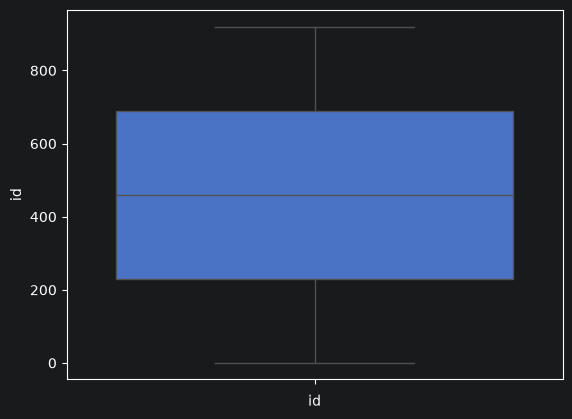

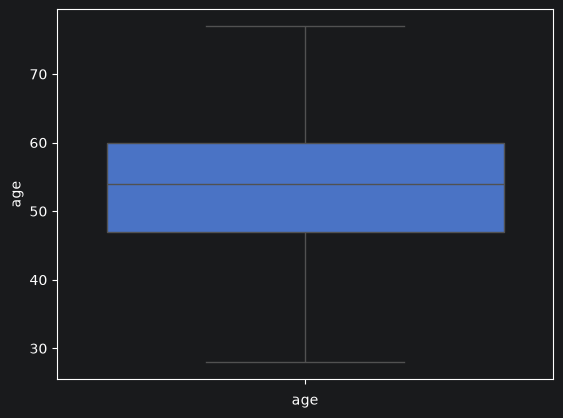

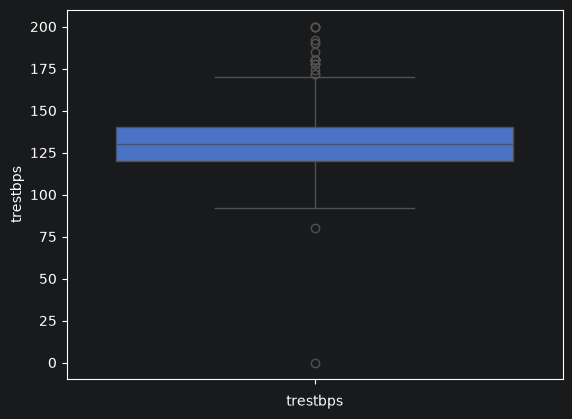

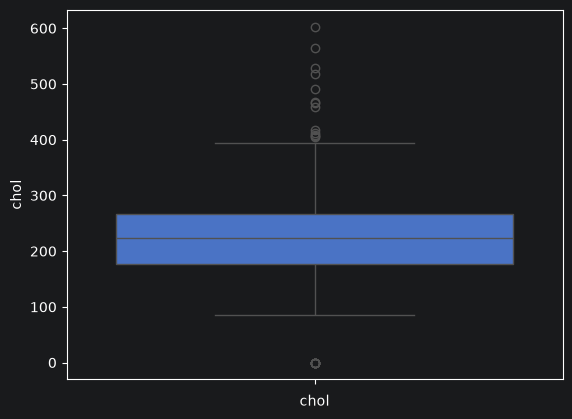

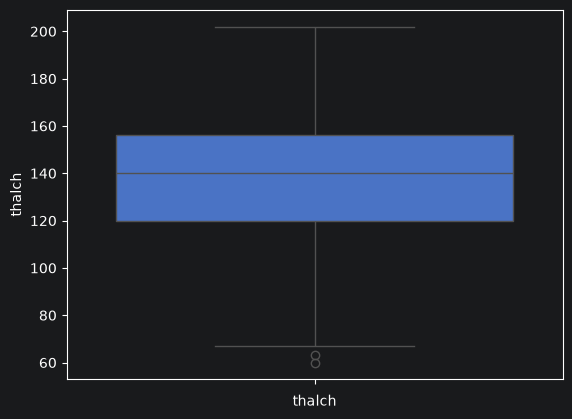

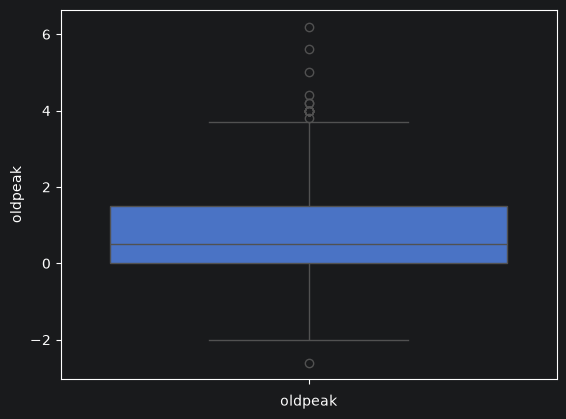

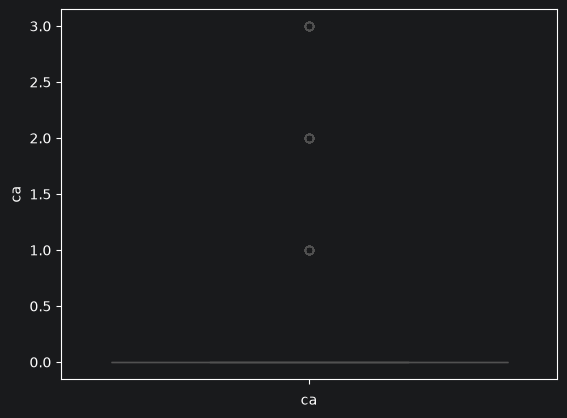

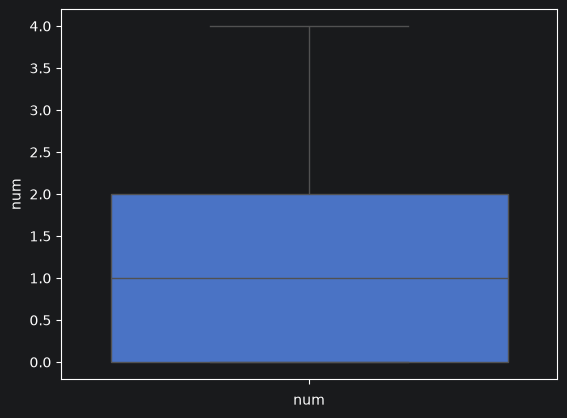

In [50]:
def plot_boxplot(data_frame: DataFrame, column_name:str )->None:
    if data_frame[column_name].dtype not in ['int', 'float']:
        return
    sns.boxplot(data_frame[column_name])
    plt.xlabel(column_name)
    plt.show()

for coluna in data_frame_encoded.columns:
    plot_boxplot(data_frame_encoded, coluna)